# 04 Final Evaluation and Diagnostics

This notebook evaluates the saved best model and generates final diagnostic outputs for the report and presentation.

## Final Evaluation Goals

- load the saved best model
- generate predictions on the test set
- inspect residual behavior
- visualize actual vs predicted values
- inspect feature importance
- compare random and chronological split summaries

## Evaluation Metrics Used

Because this is a regression project, the main metrics are `MAE`, `MSE`, `RMSE`, and `R2 Score`. These metrics are more appropriate than classification metrics such as accuracy or F1-score because the target is continuous temperature.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, MODELS_DIR, PROCESSED_DIR, TABLES_DIR
from src.train import extract_feature_importance, prediction_frame

sns.set_theme(style='whitegrid')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## Load Best Model and Test Split

In [2]:
comparison_results = pd.read_csv(TABLES_DIR / 'model_comparison_results.csv')
best_hyperparameters = pd.read_csv(TABLES_DIR / 'best_hyperparameters.csv')
tuning_comparison = pd.read_csv(TABLES_DIR / 'tuning_before_after_comparison.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'chronological_test_split.csv', parse_dates=['dt'])

chrono_results = comparison_results[comparison_results['Split Strategy'] == 'chronological'].copy()
best_row = chrono_results.sort_values('RMSE').iloc[0]
model_path = MODELS_DIR / ('best_tuned_model.joblib' if str(best_row['Tuned']).strip().lower() == 'yes' else 'best_baseline_model.joblib')
best_model = joblib.load(model_path)

print('Test split shape:', test_df.shape)
print('Best overall chronological model:', best_row['Model'])
comparison_results

Test split shape: (15000, 25)
Best overall chronological model: Random Forest


,Split Strategy,Model,Tuned,MAE,MSE,RMSE,R2 Score
0,random,Random Forest,No,0.875,1.720,1.312,0.983
1,random,XGBoost,No,0.890,1.743,1.320,0.983
2,random,Decision Tree,No,0.958,2.119,1.456,0.979
3,random,Gradient Boosting,No,0.947,2.154,1.468,0.978
4,random,Linear Regression,No,0.995,2.427,1.558,0.976
5,chronological,Random Forest,No,0.927,1.882,1.372,0.980
6,chronological,XGBoost,No,0.932,1.894,1.376,0.980
7,chronological,Gradient Boosting,No,0.965,2.126,1.458,0.978
8,chronological,Linear Regression,No,1.009,2.391,1.546,0.975
9,chronological,Decision Tree,No,1.040,2.425,1.557,0.975


## Comparative Analysis Tables

These tables make the evaluation section clearer by showing the selected parameters and the effect of tuning.

In [3]:
best_hyperparameters

,Model,Search Method,CV Folds,Iterations,Best CV RMSE,Best Parameters
0,Gradient Boosting Tuned,RandomizedSearchCV,3,4,1.4225,"{""model__learning_rate"": 0.08, ""model__max_dep..."
1,Random Forest Tuned,RandomizedSearchCV,3,4,1.4889,"{""model__max_depth"": 12, ""model__max_features""..."


In [4]:
tuning_comparison

,Baseline Model,Tuned Model,Baseline RMSE,Tuned RMSE,RMSE Change,Baseline R2,Tuned R2,R2 Change
0,Random Forest,Random Forest Tuned,1.3719,1.4935,0.1216,0.9805,0.9769,-0.0036
1,Gradient Boosting,Gradient Boosting Tuned,1.4581,1.4582,0.0001,0.9780,0.9779,-0.0000


## Generate Prediction Output

This table stores actual values, predicted values, and residuals.

In [5]:
best_predictions = prediction_frame(
    best_model,
    test_df=test_df,
    split_strategy='chronological',
    model_name=str(best_row['Model'])
)
best_predictions.to_csv(TABLES_DIR / 'best_model_predictions.csv', index=False)
best_predictions.head()

,dt,City,Country,AverageTemperature,PredictedTemperature,Residual,SplitStrategy,Model
0,1991-02-01,Kirov,Russia,-9.989,-12.117563,2.128563,chronological,Random Forest
1,1991-02-01,Middelburg,South Africa,19.756,19.873095,-0.117095,chronological,Random Forest
2,1991-02-01,Szeged,Hungary,-2.467,2.092250,-4.559250,chronological,Random Forest
3,1991-02-01,Pécs,Hungary,-1.637,2.546883,-4.183883,chronological,Random Forest
4,1991-02-01,Bhiwani,India,17.808,17.671548,0.136452,chronological,Random Forest


## Actual vs Predicted Plot

A stronger model should place most points close to the diagonal reference line.

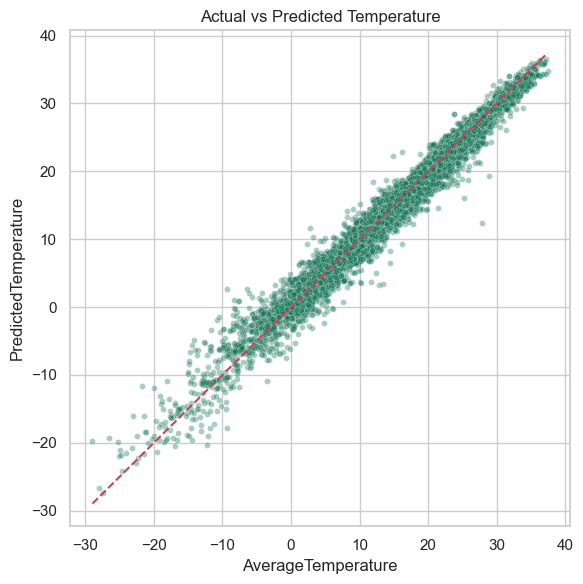

In [6]:
sample_predictions = best_predictions.sample(n=min(20000, len(best_predictions)), random_state=42)
plt.figure(figsize=(6, 6))
sns.scatterplot(data=sample_predictions, x='AverageTemperature', y='PredictedTemperature', alpha=0.35, s=18, color='#0B6E4F')
limits = [
    min(sample_predictions['AverageTemperature'].min(), sample_predictions['PredictedTemperature'].min()),
    max(sample_predictions['AverageTemperature'].max(), sample_predictions['PredictedTemperature'].max()),
]
plt.plot(limits, limits, linestyle='--', color='#BC4B51')
plt.title('Actual vs Predicted Temperature')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'actual_vs_predicted_best_model.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: The closer the cloud stays to the diagonal line, the better the model captures the true temperature pattern.

## Residual Plot

Residuals show the remaining prediction error after modeling.

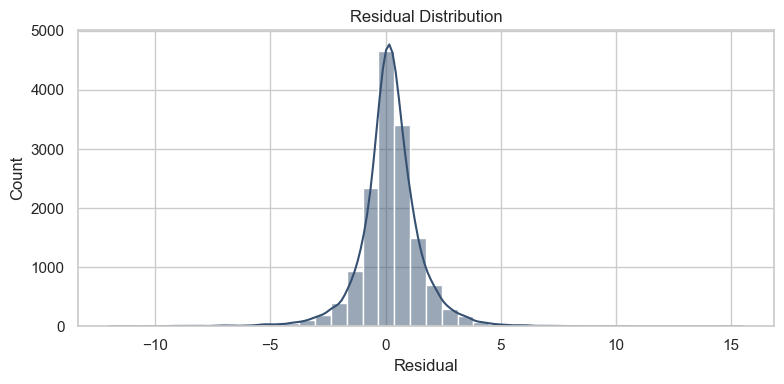

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(sample_predictions['Residual'], bins=40, kde=True, color='#355070')
plt.title('Residual Distribution')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'residual_plot.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: A centered residual distribution suggests that the model is not systematically overpredicting or underpredicting.

## Model Comparison Chart

This plot makes it easier to compare RMSE values visually across models and split strategies.

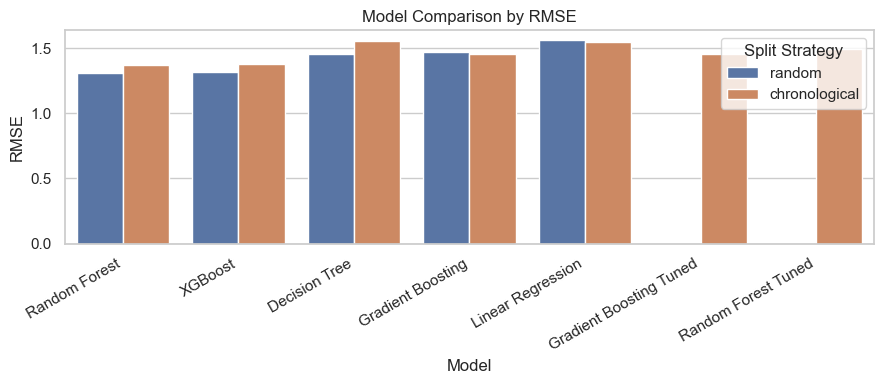

In [8]:
plt.figure(figsize=(9, 4))
sns.barplot(data=comparison_results, x='Model', y='RMSE', hue='Split Strategy')
plt.xticks(rotation=30, ha='right')
plt.title('Model Comparison by RMSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_bar_chart.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: Lower RMSE indicates better predictive accuracy. The chart also shows why chronological evaluation should be emphasized in the final discussion.

## Feature Importance

Feature importance explains which variables contribute most strongly to prediction.

In [9]:
feature_importance = extract_feature_importance(best_model, top_n=15)
feature_importance.to_csv(TABLES_DIR / 'best_model_feature_importance.csv', index=False)
feature_importance

,Feature,Importance
0,num__HistoricalCityMonthMean,0.985367
1,num__Lag12Temperature,0.004531
2,num__Lag1Temperature,0.003150
3,num__Rolling12MeanTemperature,0.001241
4,num__AverageTemperatureUncertainty,0.000933
5,num__LongitudeValue,0.000932
6,num__LatitudeValue,0.000649
7,num__YearsSince1900,0.000573
8,num__Year,0.000567
9,cat__Country_Jamaica,0.000410


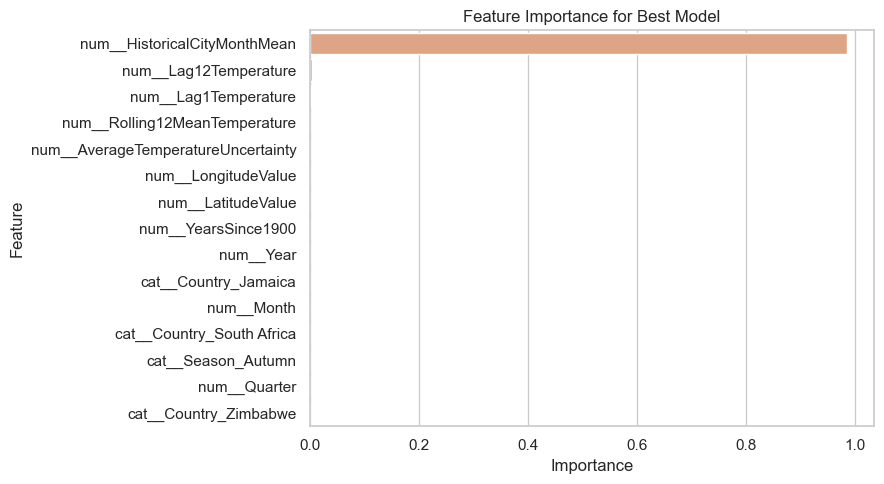

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', palette='flare', legend=False)
plt.title('Feature Importance for Best Model')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance_best_model.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: Historical climate context, especially city-month history and lag features, should appear among the strongest predictors.

## Split Strategy Summary

This final table compares average RMSE and average R2 across random and chronological evaluation.

In [11]:
split_summary = (
    comparison_results.groupby('Split Strategy', as_index=False)[['RMSE', 'R2 Score']]
    .mean()
    .sort_values('RMSE')
)
split_summary.to_csv(TABLES_DIR / 'split_strategy_summary.csv', index=False)
split_summary

,Split Strategy,RMSE,R2 Score
1,random,1.422800,0.979800
0,chronological,1.465714,0.977571


## Final Comparative Findings

- `Random Forest` is the best overall chronological model in the current results.
- `XGBoost` is the closest competitor and strengthens the comparative analysis.
- Random split gives slightly better numbers, but chronological split is more realistic for time-related climate data.
- Hyperparameter tuning improved the rigor of the workflow, but it did not beat the strongest untuned Random Forest baseline on the final chronological test set.

Final note: Random split usually looks slightly better, but chronological split is the better methodological choice for this project.